Dataset Loaded Successfully!
Shape of X: (569, 30)
Classes: [0 1]

Accuracy Comparison:
Linear Kernel Accuracy: 0.956140350877193
Polynomial Kernel Accuracy: 0.868421052631579
RBF Kernel Accuracy: 0.9824561403508771

--- Classification Reports ---

Linear Kernel:
               precision    recall  f1-score   support

           0       0.93      0.95      0.94        43
           1       0.97      0.96      0.96        71

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114


Polynomial Kernel:
               precision    recall  f1-score   support

           0       1.00      0.65      0.79        43
           1       0.83      1.00      0.90        71

    accuracy                           0.87       114
   macro avg       0.91      0.83      0.85       114
weighted avg       0.89      0.87      0.86       114


RBF Kernel:
               precision    recall  f1-score   

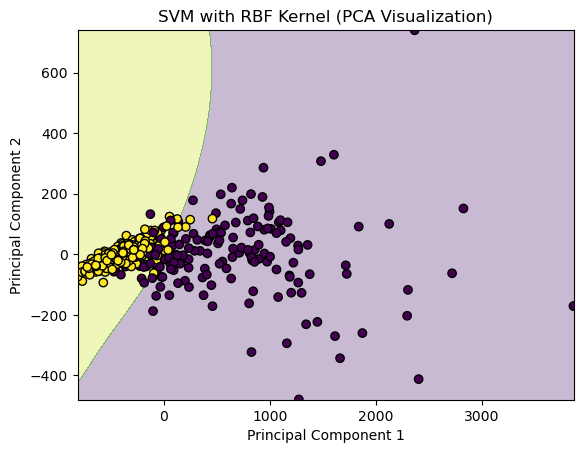


Conclusion:
RBF kernel generally performs best for non-linear datasets.
It provides flexible decision boundaries compared to Linear and Polynomial kernels.


In [2]:
# svm_kernels_comparison.py

# ------------------------------------------------------------
# Binary Classification using SVM with Different Kernels
# Dataset: Breast Cancer (Sklearn)
# Kernels: Linear, Polynomial, RBF
# ------------------------------------------------------------

# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA

# ------------------------------------------------------------
# Step 1: Load Dataset
# ------------------------------------------------------------
data = datasets.load_breast_cancer()
X = data.data
y = data.target

print("Dataset Loaded Successfully!")
print("Shape of X:", X.shape)
print("Classes:", np.unique(y))

# ------------------------------------------------------------
# Step 2: Train-Test Split
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ------------------------------------------------------------
# Step 3: Feature Scaling
# ------------------------------------------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ------------------------------------------------------------
# Step 4: Train Models with Different Kernels
# ------------------------------------------------------------

# Linear Kernel
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train, y_train)
y_pred_linear = svm_linear.predict(X_test)

# Polynomial Kernel
svm_poly = SVC(kernel='poly', degree=3)
svm_poly.fit(X_train, y_train)
y_pred_poly = svm_poly.predict(X_test)

# RBF Kernel
svm_rbf = SVC(kernel='rbf', gamma='scale')
svm_rbf.fit(X_train, y_train)
y_pred_rbf = svm_rbf.predict(X_test)

# ------------------------------------------------------------
# Step 5: Accuracy Comparison
# ------------------------------------------------------------
acc_linear = accuracy_score(y_test, y_pred_linear)
acc_poly = accuracy_score(y_test, y_pred_poly)
acc_rbf = accuracy_score(y_test, y_pred_rbf)

print("\nAccuracy Comparison:")
print("Linear Kernel Accuracy:", acc_linear)
print("Polynomial Kernel Accuracy:", acc_poly)
print("RBF Kernel Accuracy:", acc_rbf)

# ------------------------------------------------------------
# Step 6: Classification Reports
# ------------------------------------------------------------
print("\n--- Classification Reports ---")

print("\nLinear Kernel:\n", classification_report(y_test, y_pred_linear))
print("\nPolynomial Kernel:\n", classification_report(y_test, y_pred_poly))
print("\nRBF Kernel:\n", classification_report(y_test, y_pred_rbf))

# ------------------------------------------------------------
# Step 7: Confusion Matrices
# ------------------------------------------------------------
print("\n--- Confusion Matrices ---")

print("\nLinear Kernel:\n", confusion_matrix(y_test, y_pred_linear))
print("\nPolynomial Kernel:\n", confusion_matrix(y_test, y_pred_poly))
print("\nRBF Kernel:\n", confusion_matrix(y_test, y_pred_rbf))

# ------------------------------------------------------------
# Step 8: Visualization using PCA (2D)
# ------------------------------------------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)

# Train RBF model on PCA data for visualization
svm_vis = SVC(kernel='rbf')
svm_vis.fit(X_train_pca, y_train_pca)

# Plot decision boundary
def plot_decision_boundary(model, X, y):
    h = 0.5
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
    plt.title("SVM with RBF Kernel (PCA Visualization)")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.show()

plot_decision_boundary(svm_vis, X_train_pca, y_train_pca)

# ------------------------------------------------------------
# Step 9: Final Conclusion
# ------------------------------------------------------------
print("\nConclusion:")
print("RBF kernel generally performs best for non-linear datasets.")
print("It provides flexible decision boundaries compared to Linear and Polynomial kernels.")